# Problem Set 1
## Sagar Clemensen (fck916)
### 11/2-2026

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from iminuit import Minuit
from iminuit import cost
from scipy import stats
from scipy.integrate import quad

r = np.random

## Problem 1a

In [10]:
df = pd.read_csv('Liverpool10k2026.csv')
df["Time"] = (df["Time"].str.replace("O", "0", regex=False))

df["seconds"] = pd.to_timedelta(df["Time"]).dt.total_seconds()
times = df["seconds"].values
df

,First Name,Last Name,Gender,Club,Time,seconds
0,Joshua,Garcia,Male,NaN,00:42:24.00,2544.0
1,William,Young,Male,NaN,00:51:18.00,3078.0
2,Renee,Daniel,Female,NaN,00:41:29.00,2489.0
3,Timothy,Barnes,Male,NaN,00:52:25.00,3145.0
4,Juan,Hensley,Male,North Endurance,00:42:51.00,2571.0
...,...,...,...,...,...,...
193,Larry,Owens,Male,NaN,00:41:06.00,2466.0
194,Pamela,Oliver,Female,NaN,01:10:05.00,4205.0
195,Jacob,Martin,Male,Dockside Runners,00:46:38.00,2798.0
196,Kerry,Smith,Female,NaN,01:04:21.00,3861.0


In [11]:
# def GEV(x, mu, sigma, xi):
#     pdf = (1/sigma) * (1 + xi * ((x - mu) / sigma))**(-1/xi - 1) * np.exp(-(1 + xi * ((x - mu) / sigma))**(-1/xi))
#     return pdf

In [12]:
# Safe GEV function that returns 0 for invalid inputs
def GEV(x, mu, sigma, xi):
    x = np.asarray(x)
    t = 1 + xi * (x - mu) / sigma
    pdf = np.zeros_like(x, dtype=float)
    valid = t > 0
    pdf[valid] = ((1 / sigma)* t[valid]**(-1/xi - 1)* np.exp(-t[valid]**(-1/xi)))
    return pdf
def negLLHfunc(mu, sigma, xi):
    pdfVals = GEV(times, mu, sigma, xi)
    return -np.sum(np.log(pdfVals))

https://scikit-hep.org/iminuit/notebooks/cost_functions.html#Maximum-likelihood-fits

In [13]:
mfitllh = Minuit(negLLHfunc, mu=3000, sigma=600, xi=0.1)
mfitllh.errordef = Minuit.LIKELIHOOD  # important for likelihood fits!
mfitllh.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1560                       │              Nfcn = 74               │
│ EDM = 1.3e-05 (Goal: 0.0001)     │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ mu    │  2.96e3   │  0.05e3   │            │            │         │         │       │
│ 1 │ sigma │    610    │    40     │            │            │         │         │       │
│ 2 │ xi    │   -0.22   │   0.06    │            │            │         │         │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬────────────────────────────┐
│       │       mu    sigma       xi │
├───────┼────────────────────────────┤
│    mu │ 2.47e+03    0.3e3   -1.294 │
│ sigma │    0.3e3 1.33e+03   -1.277 │
│    xi │   -1.294   -1.277  0.00356 │
└───────┴────────────────────────────┘

In [14]:
muFit = mfitllh.values['mu']
sigmaFit = mfitllh.values['sigma']
xiFit = mfitllh.values['xi']

### Bootstrapping uncertainty estimation

#### Accept/Reject method

In [15]:
r.seed(42)
xmin = 2000
xmax = 5000

x_axis = np.linspace(xmin, xmax, 1000)
area = quad(lambda x: GEV(x, muFit, sigmaFit, xiFit), xmin, xmax)[0]

def GEV_renorm(x, mu, sigma, xi):
    return GEV(x, mu, sigma, xi) / area
y_axis = GEV_renorm(x_axis, muFit, sigmaFit, xiFit)
ymin = 0
ymax = np.max(y_axis)
def MC_GenAccRej():
    N_points = 198
    MC_Data = np.zeros(N_points)
    for i in range(N_points):
        
        while True:               
            
            # Range that f(x) is defined/wanted in:
            x_test = r.uniform(xmin, xmax)  
            if 1 + xiFit * ((x_test - muFit) / sigmaFit) <= 0:
                continue
            # Upper bound for function values:
            y_test = r.uniform(ymin, ymax)
            
            if (y_test < GEV_renorm(x_test, muFit, sigmaFit, xiFit)):
                break
                
        MC_Data[i] = x_test
    return MC_Data

def paramBootAccRej(Nexperiments):
    muVals = np.zeros(Nexperiments)
    sigmaVals = np.zeros(Nexperiments)
    xiVals = np.zeros(Nexperiments)
    for i in range(Nexperiments):
        dataMC = MC_GenAccRej()
        cfit = cost.UnbinnedNLL(dataMC, GEV_renorm)
        mfit = Minuit(cfit, mu=muFit, sigma=sigmaFit, xi=xiFit)
        mfit.migrad();
        muVals[i] = mfit.values['mu']
        sigmaVals[i] = mfit.values['sigma']
        xiVals[i] = mfit.values['xi']
    return muVals, sigmaVals, xiVals

In [16]:
musAR, sigmasAR, xisAR = paramBootAccRej(1000)

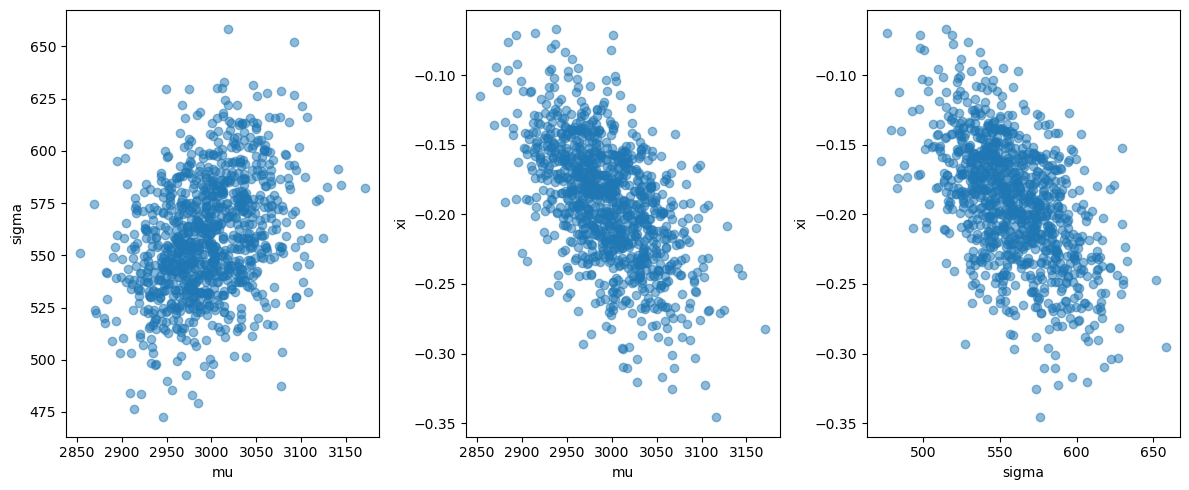

In [17]:
# Checking for correlations between parameters
fig, ax = plt.subplots(1, 3, figsize=(12, 5))
ax = ax.flatten()
ax[0].plot(musAR, sigmasAR, 'o', alpha=0.5)
ax[0].set_xlabel('mu')
ax[0].set_ylabel('sigma')
ax[1].plot(musAR, xisAR, 'o', alpha=0.5)
ax[1].set_xlabel('mu')
ax[1].set_ylabel('xi')
ax[2].plot(sigmasAR, xisAR, 'o', alpha=0.5)
ax[2].set_xlabel('sigma')
ax[2].set_ylabel('xi')
plt.tight_layout()

#### Transformation method

In [18]:
def sample_gev(N, mu, sigma, xi):
    U = np.random.uniform(size=N)
    
    if abs(xi) > 1e-8:
        return mu + (sigma/xi) * ((-np.log(U))**(-xi) - 1)
    else:
        return mu - sigma * np.log(-np.log(U))

def paramBootTrans(Nexp, Ndata):

    muVals = np.zeros(Nexp)
    sigmaVals = np.zeros(Nexp)
    xiVals = np.zeros(Nexp)

    for i in range(Nexp):

        dataMC = sample_gev(Ndata, muFit, sigmaFit, xiFit)

        cfit = cost.UnbinnedNLL(dataMC, GEV)

        mfit = Minuit(cfit, mu=muFit, sigma=sigmaFit, xi=xiFit)
        mfit.limits["sigma"] = (1e-6, None)
        mfit.limits["xi"] = (-1, 1)

        mfit.migrad()

        muVals[i] = mfit.values["mu"]
        sigmaVals[i] = mfit.values["sigma"]
        xiVals[i] = mfit.values["xi"]

    return muVals, sigmaVals, xiVals

In [19]:
r.seed(42)
musT, sigmasT, xisT = paramBootTrans(1000, len(times))

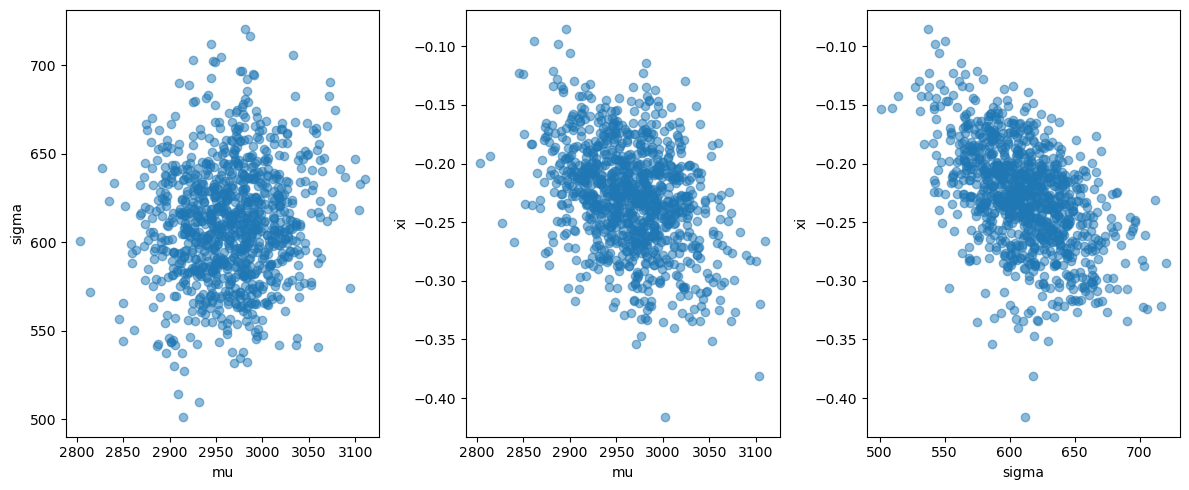

In [20]:
# Checking for correlations between parameters
fig, ax = plt.subplots(1, 3, figsize=(12, 5))
ax = ax.flatten()
ax[0].plot(musT, sigmasT, 'o', alpha=0.5)
ax[0].set_xlabel('mu')
ax[0].set_ylabel('sigma')
ax[1].plot(musT, xisT, 'o', alpha=0.5)
ax[1].set_xlabel('mu')
ax[1].set_ylabel('xi')
ax[2].plot(sigmasT, xisT, 'o', alpha=0.5)
ax[2].set_xlabel('sigma')
ax[2].set_ylabel('xi')
plt.tight_layout()

In [21]:
# 68.27% central interval percentiles
lower_p = 15.865
upper_p = 84.135

# Alpha interval
muLow, muHigh = np.percentile(musT, [lower_p, upper_p])

# Beta interval
sigmaLow, sigmaHigh = np.percentile(sigmasT, [lower_p, upper_p])
xiLow, xiHigh = np.percentile(xisT, [lower_p, upper_p])

print(f"68.27% interval for mu: [{muLow:.2f}, {muHigh:.2f}]")
print(f"68.27% interval for sigma:  [{sigmaLow:.2f}, {sigmaHigh:.2f}]")
print(f"68.27% interval for xi:  [{xiLow:.2f}, {xiHigh:.2f}]")
print(f"Best fit value for mu = {muFit:.2f} + {muHigh - muFit:.2f} - {muFit - muLow:.2f}")
print(f"Best fit value for sigma = {sigmaFit:.2f} + {sigmaHigh - sigmaFit:.2f} - {sigmaFit - sigmaLow:.2f}")
print(f"Best fit value for xi = {xiFit:.2f} + {xiHigh - xiFit:.2f} - {xiFit - xiLow:.2f}")

68.27% interval for mu: [2917.00, 3011.94]
68.27% interval for sigma:  [578.10, 643.17]
68.27% interval for xi:  [-0.27, -0.18]
Best fit value for mu = 2960.30 + 51.64 - 43.30
Best fit value for sigma = 613.68 + 29.49 - 35.58
Best fit value for xi = -0.22 + 0.04 - 0.05


In [22]:
for param in mfitllh.parameters:
    print(f"{param} = {mfitllh.values[param]:.2f} ± {mfitllh.errors[param]:.2f}")

mu = 2960.30 ± 49.70
sigma = 613.68 ± 36.44
xi = -0.22 ± 0.06


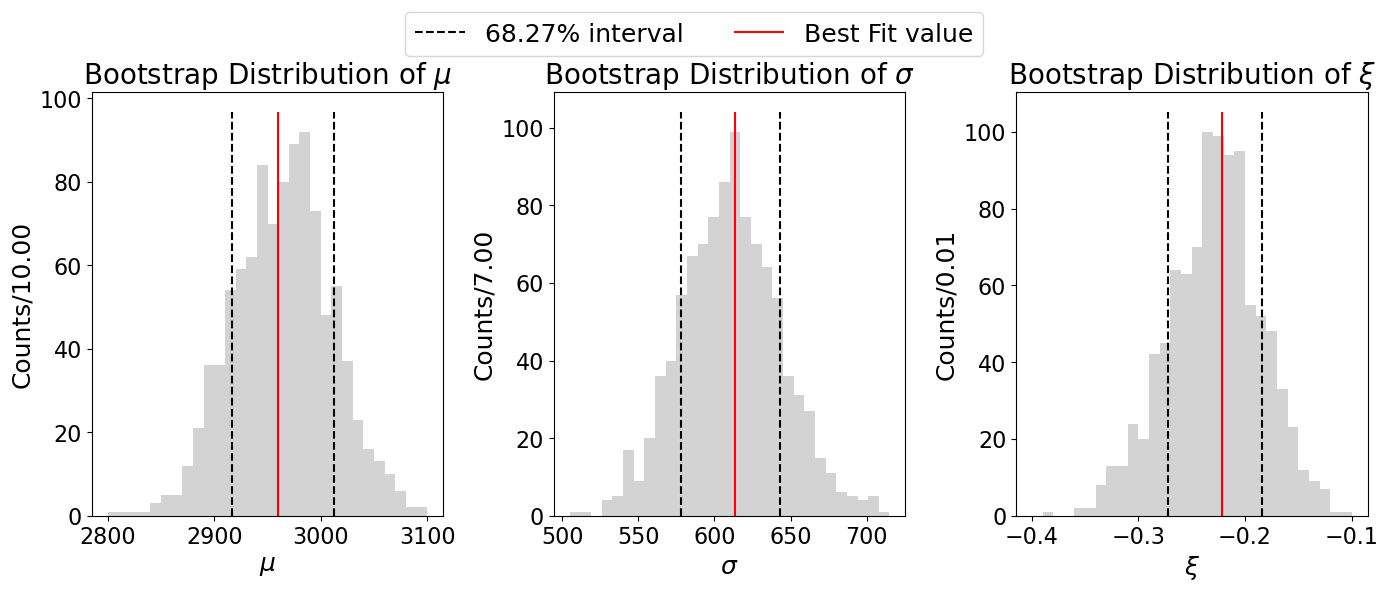

In [23]:
fig, ax = plt.subplots(1, 3, figsize=(14, 6))
ax = ax.flatten()
Nbins = 30

xminA, xmaxA = 2800, 3100
binwidth = (xmaxA - xminA) / Nbins
ax[0].hist(musT, bins=Nbins, range=(xminA, xmaxA), color='lightgray')
yminA, ymaxA = ax[0].get_ylim()
l1 = ax[0].vlines([muLow, muHigh], yminA, ymaxA, linestyles='dashed', color='black',label='68.27% interval')
l2 = ax[0].vlines(muFit, yminA, ymaxA, color='red', label='Best Fit value')
ax[0].set_xlabel("$\\mu$", fontsize=18)
ax[0].set_ylabel(f"Counts/{binwidth:.2f}", fontsize=18)
ax[0].set_title("Bootstrap Distribution of $\\mu$", fontsize=20)
ax[0].tick_params(axis='both', which='major', labelsize=16)

xminB, xmaxB = 505, 715
binwidth = (xmaxB - xminB) / Nbins
ax[1].hist(sigmasT, bins=Nbins, range=(xminB, xmaxB), color='lightgray')
yminB, ymaxB = ax[1].get_ylim()
ax[1].vlines([sigmaLow, sigmaHigh], yminB, ymaxB, linestyles='dashed', color='black', label='68.27% interval')
ax[1].vlines(sigmaFit, yminB, ymaxB, color='red', label='Best Fit value')
ax[1].set_xlabel("$\\sigma$", fontsize=18)
ax[1].set_ylabel(f"Counts/{binwidth:.2f}", fontsize=18)
ax[1].set_title("Bootstrap Distribution of $\\sigma$", fontsize=20)
ax[1].tick_params(axis='both', which='major', labelsize=16)

xminC, xmaxC = -0.4, -0.1
binwidth = (xmaxC - xminC) / Nbins
ax[2].hist(xisT, bins=Nbins, range=(xminC, xmaxC), color='lightgray')
yminC, ymaxC = ax[2].get_ylim()
ax[2].vlines([xiLow, xiHigh], yminC, ymaxC, linestyles='dashed', color='black', label='68.27% interval')
ax[2].vlines(xiFit, yminC, ymaxC, color='red', label='Best Fit value')
ax[2].set_xlabel("$\\xi$", fontsize=18)
ax[2].set_ylabel(f"Counts/{binwidth:.2f}", fontsize=18)
ax[2].set_title("Bootstrap Distribution of $\\xi$", fontsize=20)
ax[2].tick_params(axis='both', which='major', labelsize=16)

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', fontsize=18, ncol=2)

plt.tight_layout(rect=[0, 0, 1, 0.92])  # Leave space for legend
plt.show()

In [24]:
munew = np.mean(musT)
sigmanew = np.mean(sigmasT)
xinew = np.mean(xisT)
print(f"Bootstrap means for mu, sigma, xi: {munew:.2f}, {sigmanew:.2f}, {xinew:.2f}")
print(f'Best fit value for mu, sigma, xi: {muFit:.2f}, {sigmaFit:.2f}, {xiFit:.2f}')
print(negLLHfunc(munew, sigmanew, xinew), mfitllh.fval)

Bootstrap means for mu, sigma, xi: 2964.72, 610.87, -0.23
Best fit value for mu, sigma, xi: 2960.30, 613.68, -0.22
1560.062869186179 1560.0405839337218


### Plot

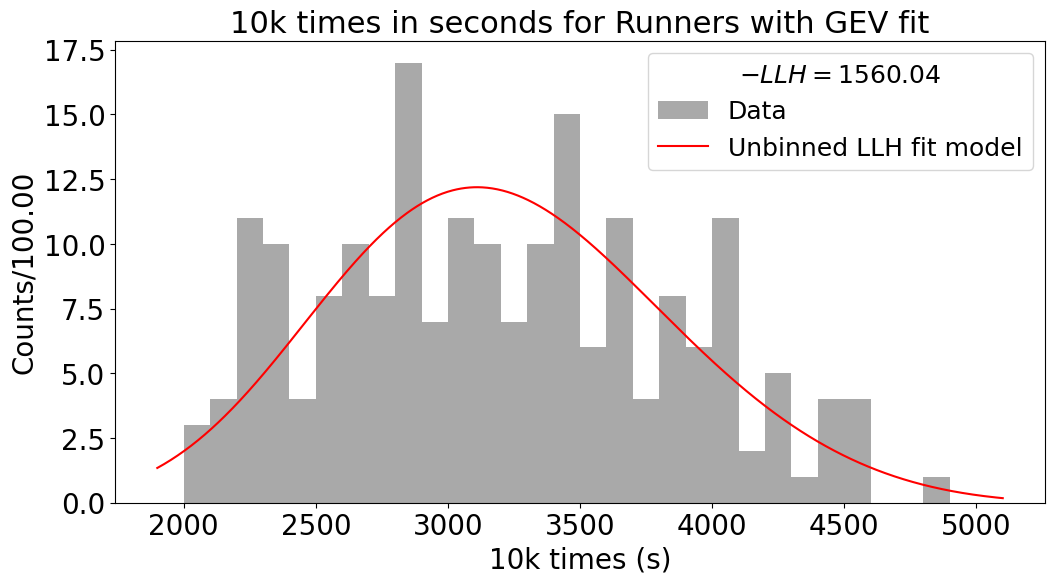

In [25]:
fig, ax = plt.subplots(figsize=(12, 6))
# print(np.min(times), np.max(times))
Nbins = 30
xmin = 2000
xmax = 5000
binwidth = (xmax - xmin) / Nbins    
ax.hist(times, bins=Nbins, range=(xmin, xmax), label='Data', color='darkgray')
llh = mfitllh.fval

ax.set_xlabel('10k times (s)', fontsize=20)
ax.set_ylabel(f'Counts/{binwidth:.2f}', fontsize=20)
ax.set_title('10k times in seconds for Runners with GEV fit', fontsize=22)
ax.tick_params(axis='both', which='major', labelsize=20)
xx = np.linspace(xmin-100, xmax+100, 1000)
ax.plot(xx, GEV(xx, *mfitllh.values[:])*len(times)*binwidth, '-r', label='Unbinned LLH fit model')

plt.legend(title=f"$-LLH = {llh:.2f}$", fontsize=18, title_fontsize = 18, alignment = 'center');

## Problem 1b

In [26]:
cutoffTime = df['seconds'][df['First Name'] == 'Tanyusha'].values[0]
# print(f"Cutoff time: {cutoffTime:.2f} seconds")
# print(times[times > cutoffTime])
NSlowData = len(times[times > cutoffTime])
fracSlowData = NSlowData / len(times)
fracSlowDataUnc = np.sqrt(fracSlowData*(1-fracSlowData)/len(times))

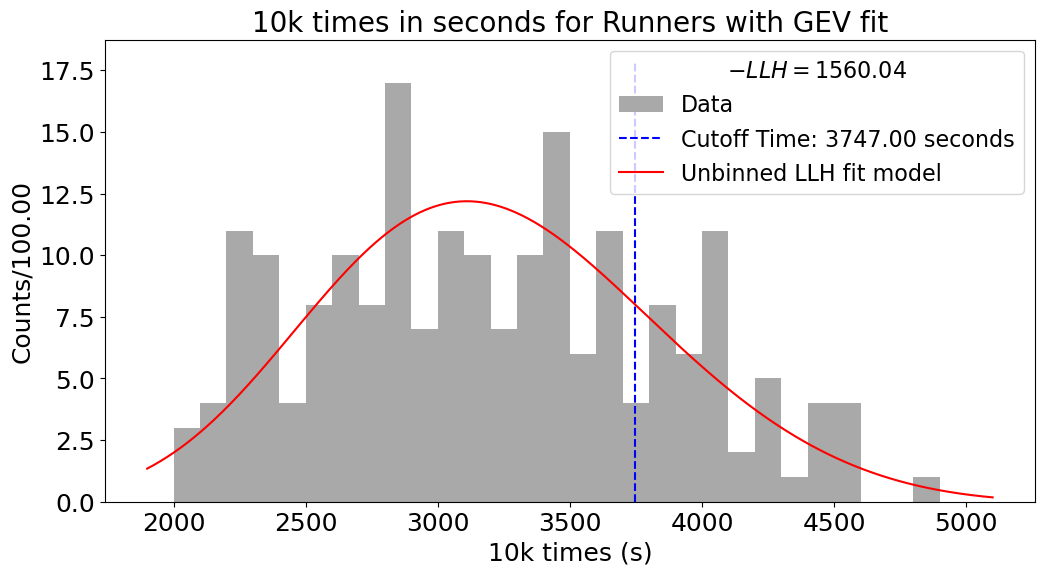

In [27]:
fig, ax = plt.subplots(figsize=(12, 6))  
ax.hist(times, bins=Nbins, range=(xmin, xmax), label='Data', color='darkgray')

ax.set_xlabel('10k times (s)', fontsize=18)
ax.set_ylabel(f'Counts/{binwidth:.2f}', fontsize=18)
ax.set_title('10k times in seconds for Runners with GEV fit', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.vlines(x=cutoffTime, ymin=0, ymax=ax.get_ylim()[1], colors='blue', linestyles='dashed', label=f'Cutoff Time: {cutoffTime:.2f} seconds')
ax.plot(xx, GEV(xx, *mfitllh.values[:])*binwidth*len(times), '-r', label='Unbinned LLH fit model')
fit_info = [f"$-LLH = {-llh:.2f}$",]

plt.legend(title=f"$-LLH = {llh:.2f}$", fontsize=16, title_fontsize = 16, alignment = 'center');

In [28]:
def GEVcdf(x, mu, sigma, xi):
    cdf = np.exp(-1*(1 + xi * ((x - mu) / sigma))**(-1/xi))
    return cdf
xmin = cutoffTime
xmax = muFit-sigmaFit/xiFit
fracSlowFit = quad(GEV, xmin, xmax, args=(muFit, sigmaFit, xiFit))[0]
fracSlowFitUnc = quad(GEV, xmin, xmax, args=(muFit, sigmaFit, xiFit))[1]

In [29]:
analytic = 1 - GEVcdf(cutoffTime, muFit, sigmaFit, xiFit)
print(analytic, fracSlowFit, fracSlowFitUnc)

0.19849883241235833 0.19849883241264427 5.066168346406158e-11


In [31]:
zval = np.abs((fracSlowFit - fracSlowData) / np.sqrt(fracSlowDataUnc**2 + fracSlowFitUnc**2))
pval = 2 * stats.norm.sf(zval)
print(f"Fraction of runners slower than {cutoffTime:.2f} seconds: {fracSlowData:.3f} ± {fracSlowDataUnc:.3f}")
print(f"Analytic result: {analytic:.4f}, Numerical result: {fracSlowFit:.11f} ± {fracSlowFitUnc:.11f}")
print(f"Z-value: {zval:.4f}, P-value: {pval:.4f}")

(.23-.1985)/.03

Fraction of runners slower than 3747.00 seconds: 0.227 ± 0.030
Analytic result: 0.1985, Numerical result: 0.19849883241 ± 0.00000000005
Z-value: 0.9661, P-value: 0.3340


1.05

## Problem 1c

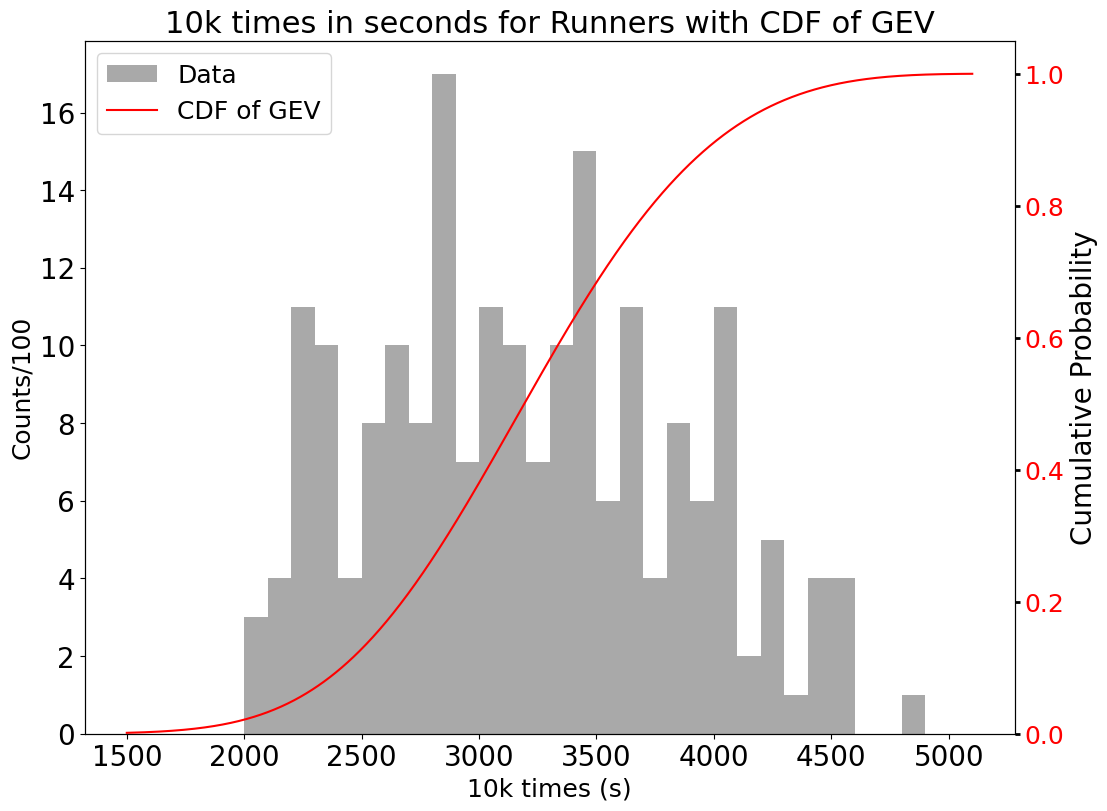

In [90]:
muC = 2980
sigmaC = 607.5
xiC = -0.26

fig, ax1 = plt.subplots(figsize=(12, 9))
Nbins=30
xmin = 2000
xmax = 5000
binwidth = (xmax - xmin) / Nbins
ax1.set_xlabel('10k times (s)', fontsize=18)
ax1.set_ylabel(f'Counts/{binwidth:.0f}', fontsize=18)

n, bins, patches = ax1.hist(times, bins=Nbins, range=(xmin, xmax), label='Data', color='darkgray')

## Separate y-axis for the CDF going from 0 to 1
ax2 = ax1.twinx()
xx = np.linspace(xmin-500, xmax+100, 1000)
line2, = ax2.plot(xx, GEVcdf(xx, muC, sigmaC, xiC), '-r', label='CDF of GEV')
# ax.set_xlabel('10k times (s)', fontsize=18)
ax2.set_ylabel('Cumulative Probability', fontsize=20)
ax1.set_title('10k times in seconds for Runners with CDF of GEV', fontsize=22)
ax1.tick_params(axis='both', which='major', labelsize=20)
ax2.tick_params(axis='y', width=2, labelcolor='red', labelsize=18)
lines = [patches[0], line2]
labels = ['Data', 'CDF of GEV']
ax1.legend(lines, labels, loc='upper left', fontsize=18)
ax1.set_ylim(bottom=0)
ax2.set_ylim(0, 1.05);

In [24]:
fastest = np.min(times)
print(f"Fastest time: {fastest:.2f} seconds")
PFaster = GEVcdf(fastest, muC, sigmaC, xiC)
print(f"Probability of a runner being faster than {fastest:.2f} seconds: {PFaster:.4f}")

Fastest time: 2005.00 seconds
Probability of a runner being faster than 2005.00 seconds: 0.0218


## Problem 2

### By solving the equation $\frac{1}{N}\cdot1.6 + \frac{2.66}{N}\cdot0.5 = 1$ for N, we get $N = 2.93$.

In [25]:
def prior(x):
    N = 2.93
    result = np.zeros_like(x)
    result[(x > 0) & (x <= 1.6)] = 1 / N
    result[(x > 1.6) & (x <= 2.1)] = 2.66 / N
    result[(x <= 0) | (x > 2.1)] = 0
    return result
def likelihood(x):
    alpha = 2
    beta = 2
    return stats.gamma.pdf(x, a=alpha, scale=1/beta)
def posterior(x):
    return likelihood(x) * prior(x)

In [26]:
xvals = np.linspace(0, 4, 1000, endpoint=False)[1:]
NLh = quad(likelihood, xvals[0], xvals[-1])[0]
NPost = quad(posterior, xvals[0], xvals[-1])[0]
print(f"Normalization Constants: Likelihood = {NLh:.4f}, Posterior = {NPost:.4f}")

Normalization Constants: Likelihood = 0.9969, Posterior = 0.3675


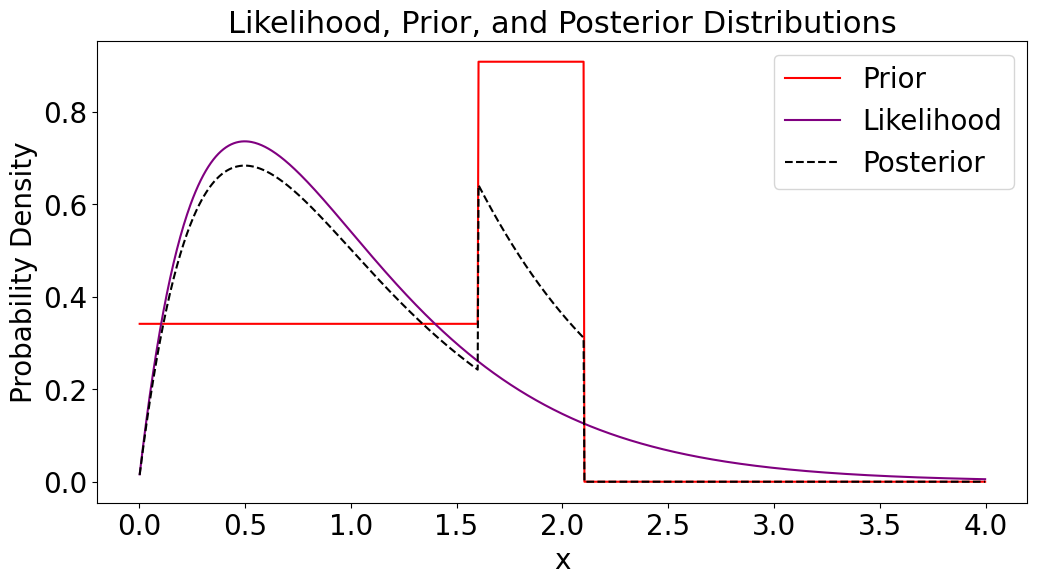

In [27]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(xvals, prior(xvals), label='Prior', color='red')
ax.plot(xvals, likelihood(xvals), label='Likelihood', color='purple')
ax.plot(xvals, likelihood(xvals) * prior(xvals)/NPost, '--', label='Posterior', color='black')
ax.legend(fontsize=20)
ax.set_xlabel('x', fontsize=20)
ax.set_ylabel('Probability Density', fontsize=20)
ax.set_title('Likelihood, Prior, and Posterior Distributions', fontsize=22)
ax.tick_params(axis='both', which='major', labelsize=20)

In [91]:
xEst = xvals[np.argmax(posterior(xvals)/NPost)]
print(np.max(posterior(xvals[:250])/NPost), np.max(posterior(xvals[250:])/NPost))
print(f"Estimated x that maximizes the posterior: {xEst:.4f}")
print(f"Posterior at xEst: {posterior(xEst)/NPost:.6f}")

0.6833186585307411 0.6409395333415869
Estimated x that maximizes the posterior: 0.5000
Posterior at xEst: 0.683319


## Problem 3a

In [29]:
r = np.random
r.seed(42)
pos = [(3.6, -2)]
Nmoves = 0
R = 5
step = 0.2
diffs = []
while True:
    theta = r.uniform(0, 2*np.pi)
    x0, y0 = pos[-1]
    vx = np.cos(theta)
    vy = np.sin(theta)

    xMove = x0 + vx * step
    yMove = y0 + vy * step
    dist = np.sqrt(xMove**2 + yMove**2)
    if dist > R:
        scale = R / dist
        xMove *= scale
        yMove *= scale
        # print(f"Move scaled to stay within the island: ({xMove:.2f}, {yMove:.2f})")

    pos.append((xMove, yMove))
    diffs.append(np.sqrt((xMove - x0)**2 + (yMove - y0)**2))
    Nmoves += 1
    if Nmoves == 200:
        break

pos = np.array(pos)
diffs = np.array(diffs)
print(len(pos))
# print(diffs[~np.isclose(diffs, step)])

201


### For fun

In [30]:
# Load the JPG image
import matplotlib.image as mpimg
palm = mpimg.imread('palm.png')
ship = mpimg.imread('ship.png')
treasure = mpimg.imread('treasure.png')

5.000000000000001 3.5457009729542057


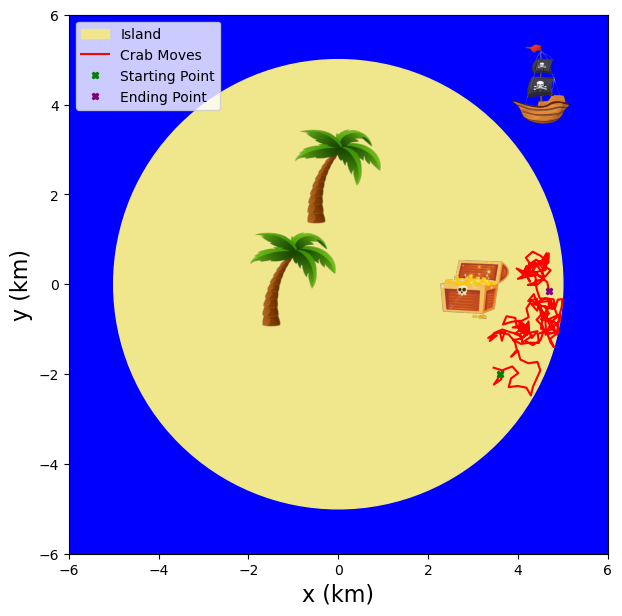

In [31]:
fig, ax = plt.subplots(figsize=(7, 7))
circle = plt.Circle((0, 0), 5, color='khaki', label='Island', alpha = 1)
radii = np.sqrt(pos[:, 0]**2 + pos[:, 1]**2)
ax.set_facecolor('blue')
ax.add_patch(circle)
ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)
ax.set_aspect('equal')
ax.plot(pos[1:, 0], pos[1:, 1], '-', color = 'red', markersize=3, label='Crab Moves')
ax.plot(pos[0, 0], pos[0, 1], 'X', color = 'green', markersize=5, label='Starting Point')
ax.plot(pos[-1, 0], pos[-1, 1], 'X', color = 'purple', markersize=5, label='Ending Point')
ax.imshow(palm, extent=[-2, 0, -1, 1.2], zorder=1)
ax.imshow(palm, extent=[-1, 1, 1.3, 3.5], zorder=1)
ax.imshow(ship, extent=[3.5, 5.5, 3.5, 5.5], zorder=1)
ax.imshow(treasure, extent=[2, 4, -1, 1], zorder=1)
ax.set_xlabel('x (km)', fontsize=16)
ax.set_ylabel('y (km)', fontsize=16)
ax.legend(loc='upper left');
print(np.max(radii), np.min(radii))

### Serious

5.000000000000001 3.5457009729542057


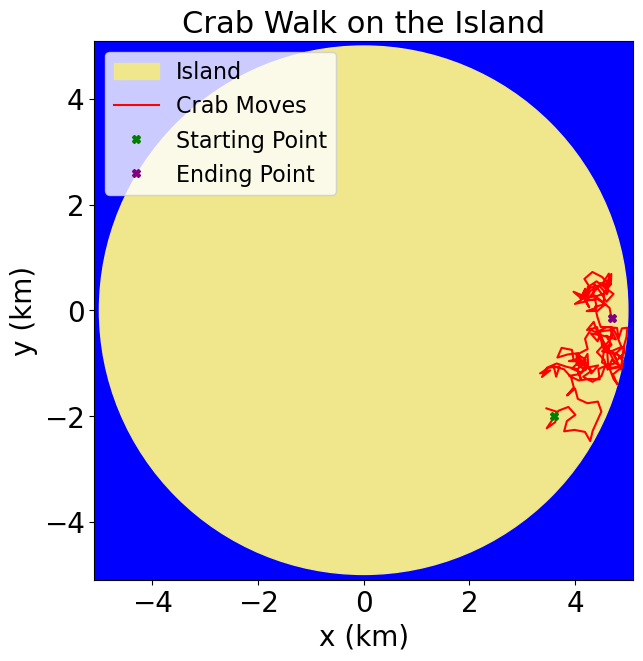

In [101]:
fig, ax = plt.subplots(figsize=(7, 7))
circle = plt.Circle((0, 0), 5, color='khaki', label='Island', alpha = 1)
radii = np.sqrt(pos[:, 0]**2 + pos[:, 1]**2)
ax.set_facecolor('blue')
ax.add_patch(circle)
ax.set_xlim(-5.1, 5.1)
ax.set_ylim(-5.1, 5.1)
ax.set_aspect('equal')
ax.plot(pos[1:, 0], pos[1:, 1], '-', color = 'red', label='Crab Moves')
ax.plot(pos[0, 0], pos[0, 1], 'X', color = 'green', markersize=6, label='Starting Point')
ax.plot(pos[-1, 0], pos[-1, 1], 'X', color = 'purple', markersize=6, label='Ending Point')
ax.set_xlabel('x (km)', fontsize=20)
ax.set_ylabel('y (km)', fontsize=20)
ax.set_title('Crab Walk on the Island', fontsize=22)
ax.tick_params(axis='both', which='major', labelsize=20)
ax.legend(loc='upper left', fontsize=16);
print(np.max(radii), np.min(radii))

## Problem 3b

In [33]:
def crab_travel(Nexperiments):
    distances = np.zeros(Nexperiments)
    for i in range(Nexperiments):
        x = 3.6
        y = -2
        R = 5
        step = 0.2
        total_dist = 0
        while True:
            theta = r.uniform(0, 2*np.pi)
            vx = np.cos(theta)
            vy = np.sin(theta)
            dist = np.sqrt((vx*step)**2 + (vy*step)**2)
            x += vx*step
            y += vy*step
            if np.sqrt(x**2 + y**2) > R:
                scale = R / np.sqrt(x**2 + y**2)
                xdum = x - vx*step
                ydum = y - vy*step
                x *= scale
                y *= scale
                total_dist += np.sqrt((x-xdum)**2+(y-ydum)**2)
                break
            total_dist += dist
        distances[i] = total_dist
    return distances

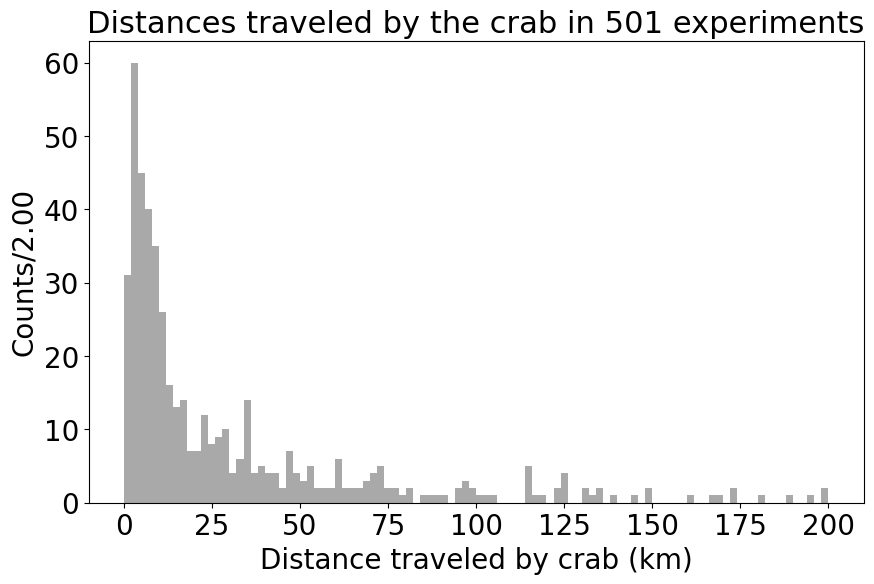

In [34]:
r.seed(42)
distTravel = crab_travel(501)
xmin = 0
xmax = 200
Nbins = 100
binwidth = (xmax - xmin) / Nbins
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(distTravel, bins=Nbins, range=(xmin, xmax), label='Data', color='darkgray')
ax.set_xlabel('Distance traveled by crab (km)', fontsize=20)
ax.set_ylabel(f'Counts/{binwidth:.2f}', fontsize=20)
ax.set_title('Distances traveled by the crab in 501 experiments', fontsize=22)
ax.tick_params(axis='both', which='major', labelsize=20)

## Problem 3c

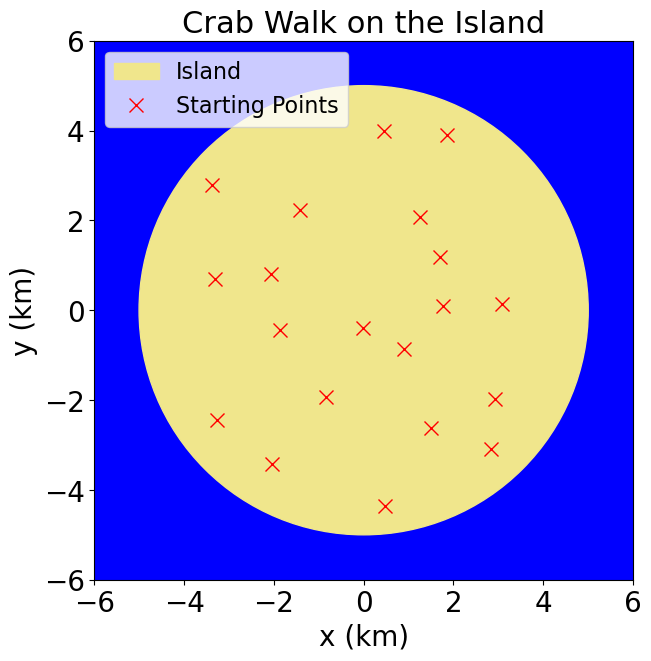

In [3]:
crabPosOriginal = np.loadtxt('CrabStartPositions.txt')
fig, ax = plt.subplots(figsize=(7, 7))
circle = plt.Circle((0, 0), 5, color='khaki', label='Island', alpha = 1)
ax.set_facecolor('blue')
ax.add_patch(circle)
ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)
ax.set_aspect('equal')
ax.plot(crabPosOriginal[:, 0], crabPosOriginal[:, 1], 'x', color = 'red', markersize=10, label='Starting Points')
ax.set_xlabel('x (km)', fontsize=20)
ax.set_ylabel('y (km)', fontsize=20)
ax.set_title('Crab Walk on the Island', fontsize=22)
ax.tick_params(axis='both', which='major', labelsize=20)
ax.legend(loc='upper left', fontsize=16);

In [142]:
import numpy as np

def crabOdds(m1, m2):
    # Determine which input is larger
    if m1 > m2:
        mLarge, mSmall = m1, m2
        large_index = 0
    elif m2 > m1:
        mLarge, mSmall = m2, m1
        large_index = 1
    else:  # m1 == m2
        mLarge, mSmall = m1, m2
        large_index = np.random.choice([0, 1])  # Randomly choose which one is "large" if they are equal
    odds = mLarge**2 / (mSmall**2 + mLarge**2)
    if np.random.rand() < odds:
        mLarge += mSmall
        mSmall = 0

    # Return in original order
    if large_index == 0:
        return mLarge, mSmall
    else:
        return mSmall, mLarge
crabOdds(1, 1)

(2, 0)

In [ ]:
def crabOdds(m1, m2):
    masses = np.array([m1, m2])
    mSorted = np.sort([m1, m2])
    args = np.argsort([m1, m2])
    mLarge = mSorted[1]
    mSmall = mSorted[0]
    odds = mLarge**2/(mSmall**2 + mLarge**2)
    a = r.rand(1)
    if a < odds:
        mLarge += mSmall
        mSmall = 0
    masses[args] = [mLarge, mSmall]
    return mLarge, mSmall

### Original version, slow for large N

In [ ]:
# from scipy.spatial.distance import pdist, squareform

# def crabOdds(m1, m2):
#     # Determine which input is larger
#     if m1 > m2:
#         mLarge, mSmall = m1, m2
#         large_index = 0
#     elif m2 > m1:
#         mLarge, mSmall = m2, m1
#         large_index = 1
#     else:  # m1 == m2
#         mLarge, mSmall = m1, m2
#         large_index = np.random.choice([0, 1])  # Randomly choose which one is "large" if they are equal
#     odds = mLarge**2 / (mSmall**2 + mLarge**2)
#     if np.random.rand() < odds:
#         mLarge += mSmall
#         mSmall = 0

#     # Return in original order
#     if large_index == 0:
#         return mLarge, mSmall
#     else:
#         return mSmall, mLarge

# def crabmove(x0, y0, step=0.2, R=5):
#     theta = r.uniform(0, 2*np.pi)
#     vx = np.cos(theta)
#     vy = np.sin(theta)

#     xMove = x0 + vx * step
#     yMove = y0 + vy * step

#     dist = np.sqrt(xMove**2 + yMove**2)
#     if dist > R:
#         scale = R / dist
#         xMove *= scale
#         yMove *= scale

#     return xMove, yMove

# def crabBattle(Nexperiments):
#     NCrabs = np.zeros(Nexperiments, dtype=int)
#     mMaxCrab = np.zeros(Nexperiments, dtype=int)

#     for exp in range(Nexperiments):   # renamed outer index
#         Ndays = 0
#         crabPos = crabPosOriginal.copy()
#         crabMass = np.ones(len(crabPos))

#         while True:
#             # Move crabs
#             for k in range(len(crabPos)):
#                 crabPos[k] = crabmove(*crabPos[k])

#             # Resolve fights one at a time (closest first)
#             while True:
#                 if len(crabPos) < 2:
#                     break

#                 distances = squareform(pdist(crabPos))
#                 pairs = []

#                 # Collect all pairs within fight distance
#                 for a in range(len(crabPos)):
#                     for b in range(a+1, len(crabPos)):
#                         if distances[a, b] < 0.175:
#                             pairs.append((distances[a, b], a, b))

#                 # Stop if no fights remain
#                 if not pairs:
#                     break

#                 # Closest fight happens first
#                 pairs.sort()
#                 _, a, b = pairs[0]

#                 # Fight
#                 crabMass[a], crabMass[b] = crabOdds(crabMass[a], crabMass[b])

#                 # Remove dead crabs immediately
#                 alive = crabMass > 0
#                 crabPos = crabPos[alive]
#                 crabMass = crabMass[alive]

#             if np.sum(crabMass) != 20:
#                 print('Error')

#             Ndays += 1
#             if Ndays == 200:
#                 break

#         NCrabs[exp] = len(crabMass)
#         mMaxCrab[exp] = np.max(crabMass)

#     return NCrabs, mMaxCrab

### Numba version, much faster for large N

In [172]:
from numba import njit

@njit
def crabmove(x0, y0, step=0.2, R=5.0):
    theta = np.random.random() * 2.0 * np.pi
    vx = np.cos(theta)
    vy = np.sin(theta)

    xMove = x0 + vx * step
    yMove = y0 + vy * step

    dist = np.sqrt(xMove**2 + yMove**2)
    if dist > R:
        scale = R / dist
        xMove *= scale
        yMove *= scale
    return xMove, yMove

@njit
def crabOdds(m1, m2):
    if m1 >= m2:
        mLarge = m1
        mSmall = m2
        large_first = True
    else:
        mLarge = m2
        mSmall = m1
        large_first = False
    # else:  # m1 == m2
    #     mLarge = m1
    #     mSmall = m2
    #     large_first = np.random.random() < 0.5  # Randomly choose which one is "large" if they are equal

    odds = (mLarge*mLarge) / (mSmall*mSmall + mLarge*mLarge)

    if np.random.random() < odds:
        mLarge = mLarge + mSmall
        mSmall = 0.0

    if large_first:
        return mLarge, mSmall
    else:
        return mSmall, mLarge

@njit
def crabBattle(Nexperiments, crabPosOriginal=crabPosOriginal):

    N0 = crabPosOriginal.shape[0]

    NCrabs = np.zeros(Nexperiments, dtype=np.int64)
    mMaxCrab = np.zeros(Nexperiments)

    fight_dist2 = 0.175*0.175

    for exp in range(Nexperiments):

        crabPos = crabPosOriginal.copy()
        crabMass = np.ones(N0)

        n_alive = N0
        Ndays = 0

        while Ndays < 200:

            # ---------------------
            # Move crabs
            # ---------------------
            for k in range(n_alive):
                x, y = crabPos[k, 0], crabPos[k, 1]
                xnew, ynew = crabmove(x, y)
                crabPos[k, 0] = xnew
                crabPos[k, 1] = ynew

            # ---------------------
            # Resolve fights
            # ---------------------
            while True:

                if n_alive < 2:
                    break

                best_d = 1e12
                best_a = -1
                best_b = -1

                # Find closest fighting pair
                for i in range(n_alive):
                    xi, yi = crabPos[i, 0], crabPos[i, 1]
                    for j in range(i+1, n_alive):
                        dx = xi - crabPos[j, 0]
                        dy = yi - crabPos[j, 1]
                        d2 = dx*dx + dy*dy

                        if d2 < fight_dist2 and d2 < best_d:
                            best_d = d2
                            best_a = i
                            best_b = j

                if best_a == -1:
                    break  # no fights

                # Fight
                m1 = crabMass[best_a]
                m2 = crabMass[best_b]
                m1, m2 = crabOdds(m1, m2)
                crabMass[best_a] = m1
                crabMass[best_b] = m2

                # Remove dead via swap-with-last
                if crabMass[best_a] == 0.0:
                    crabPos[best_a] = crabPos[n_alive-1]
                    crabMass[best_a] = crabMass[n_alive-1]
                    n_alive -= 1

                if crabMass[best_b] == 0.0 and best_b < n_alive:
                    crabPos[best_b] = crabPos[n_alive-1]
                    crabMass[best_b] = crabMass[n_alive-1]
                    n_alive -= 1

            # Optional mass check
            total_mass = 0.0
            for i in range(n_alive):
                total_mass += crabMass[i]
            if total_mass != 20.0:
                pass  # avoid print inside njit

            Ndays += 1

        NCrabs[exp] = n_alive

        max_mass = 0.0
        for i in range(n_alive):
            if crabMass[i] > max_mass:
                max_mass = crabMass[i]
        mMaxCrab[exp] = max_mass

    return NCrabs, mMaxCrab

### Plots

In [ ]:
# crabs, masses = crabBattle(100000)
# np.savetxt('CrabBattleResults.txt', np.column_stack((crabs, masses)), fmt='%d %.1f')

In [153]:
crabs, masses = np.loadtxt('CrabBattleResults.txt', unpack=True)
crabs = crabs.astype(int)
masses = masses.astype(float)
print(crabs)

[12 10 10 ... 12 12 13]


The most likely amount of crabs remaining alive after 200 days is 11
The most likely mass of the largest crab is 3


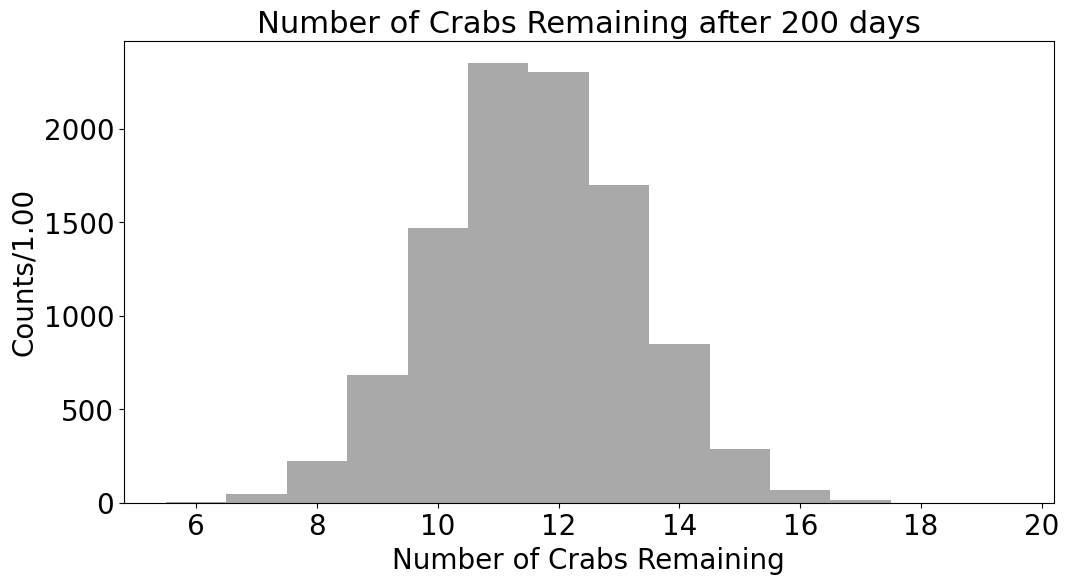

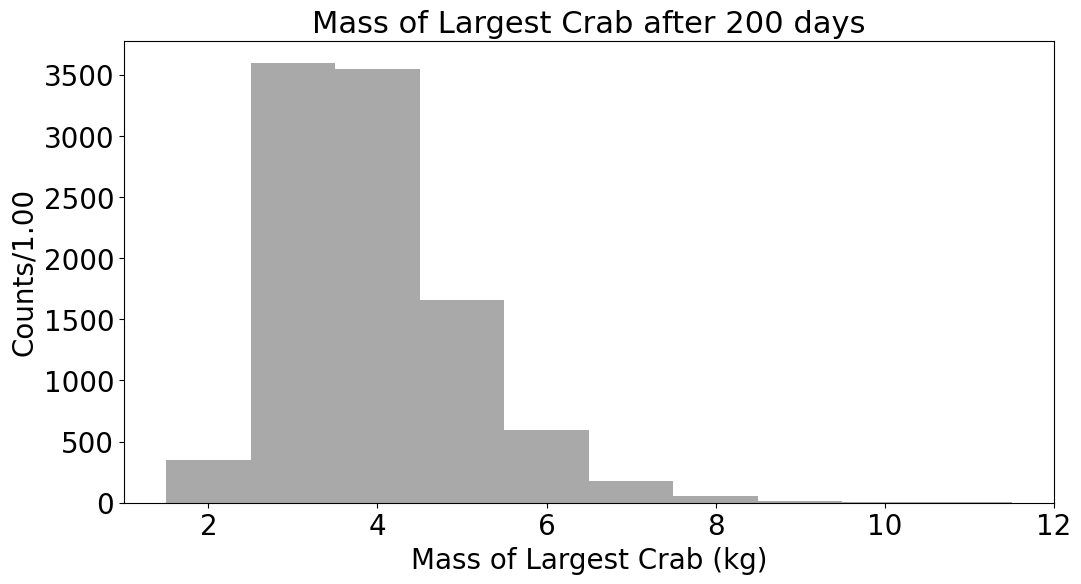

In [173]:
crabs, masses = crabBattle(10000)
fig,ax = plt.subplots(figsize=(12, 6))
xmin, xmax = np.min(crabs)-0.5, np.max(crabs)+0.5
Nbins = int(xmax - xmin)
binwidth = (xmax - xmin) / Nbins
ax.hist(crabs, bins=Nbins, range=(xmin, xmax), label='Data', color='darkgray')
ax.set_xlabel('Number of Crabs Remaining', fontsize=20)
ax.set_ylabel(f'Counts/{binwidth:.2f}', fontsize=20)
ax.set_title('Number of Crabs Remaining after 200 days', fontsize=22)
ax.tick_params(axis='both', which='major', labelsize=20)

fig,ax = plt.subplots(figsize=(12, 6))
xmin, xmax = np.min(masses)-0.5, np.max(masses)+0.5
Nbins = int(xmax - xmin)
binwidth = (xmax - xmin) / Nbins
ax.hist(masses, bins=Nbins, range=(xmin, xmax), label='Data', color='darkgray')
ax.set_xlabel('Mass of Largest Crab (kg)', fontsize=20)
ax.set_ylabel(f'Counts/{binwidth:.2f}', fontsize=20)
ax.set_title('Mass of Largest Crab after 200 days', fontsize=22)
ax.tick_params(axis='both', which='major', labelsize=20)
print('The most likely amount of crabs remaining alive after 200 days is', stats.mode(crabs)[0])
print('The most likely mass of the largest crab is', int(stats.mode(masses)[0]))

In [157]:
countsCrabs = np.bincount(crabs)
countsMasses = np.bincount(masses.astype(int))
print(countsCrabs)
print(countsMasses)

[ 0  0  0  0  0  0  0  0  1  5 15 15 30 21 10  3]
[ 0  0  1 38 33 19  8  0  1]


## Problem 3d

### Original version

In [ ]:
# def crabBattleV2(Nexperiments):
#     days10 = np.zeros(Nexperiments, dtype=int)

#     for exp in range(Nexperiments):   # renamed outer index
#         Ndays = 0
#         crabPos = crabPosOriginal.copy()
#         crabMass = np.ones(len(crabPos))

#         while True:
#             Ndays += 1
#             # Move crabs
#             for k in range(len(crabPos)):
#                 crabPos[k] = crabmove(*crabPos[k])

#             # Resolve fights one at a time (closest first)
#             while True:
#                 if len(crabPos) < 2:
#                     break

#                 distances = squareform(pdist(crabPos))
#                 pairs = []

#                 # Collect all pairs within fight distance
#                 for a in range(len(crabPos)):
#                     for b in range(a+1, len(crabPos)):
#                         if distances[a, b] < 0.175:
#                             pairs.append((distances[a, b], a, b))

#                 # Stop if no fights remain
#                 if not pairs:
#                     break

#                 # Closest fight happens first
#                 pairs.sort(key=lambda x: x[0])
#                 _, a, b = pairs[0]

#                 # Fight
#                 crabMass[a], crabMass[b] = crabOdds(crabMass[a], crabMass[b])

#                 # Remove dead crabs immediately
#                 alive = crabMass > 0
#                 crabPos = crabPos[alive]
#                 crabMass = crabMass[alive]
                
#                 if len(crabMass) == 10:
#                     days10[exp] = Ndays
#                     break

#             # 10 is reached, exit outer loop too
#             if len(crabMass) == 10:
#                 break
#         days10[exp] = Ndays
#     return days10

### Numba version

In [162]:
@njit
def crabBattleV2_numba(Nexperiments, crabPosOriginal=crabPosOriginal):

    days10 = np.zeros(Nexperiments, dtype=np.int64)

    for exp in range(Nexperiments):

        Ndays = 0

        crabPos = crabPosOriginal.copy()
        crabMass = np.ones(crabPos.shape[0])

        # Track alive crabs using mask instead of shrinking arrays
        alive = np.ones(crabPos.shape[0], dtype=np.bool_)

        while True:
            Ndays += 1

            # Move crabs
            for k in range(crabPos.shape[0]):
                if alive[k]:
                    crabPos[k] = crabmove(crabPos[k, 0], crabPos[k, 1])

            while True:

                # Count alive
                nalive = 0
                for i in range(alive.shape[0]):
                    if alive[i]:
                        nalive += 1

                if nalive < 2:
                    break

                # Find closest fighting pair manually
                min_dist = 1e9
                min_a = -1
                min_b = -1

                for a in range(crabPos.shape[0]):
                    if not alive[a]:
                        continue
                    for b in range(a + 1, crabPos.shape[0]):
                        if not alive[b]:
                            continue

                        dx = crabPos[a, 0] - crabPos[b, 0]
                        dy = crabPos[a, 1] - crabPos[b, 1]
                        dist = np.sqrt(dx*dx + dy*dy)

                        if dist < 0.175 and dist < min_dist:
                            min_dist = dist
                            min_a = a
                            min_b = b

                # No fights found
                if min_a == -1:
                    break

                # Fight
                m1, m2 = crabOdds(crabMass[min_a], crabMass[min_b])
                crabMass[min_a] = m1
                crabMass[min_b] = m2

                # Remove dead
                if crabMass[min_a] <= 0:
                    alive[min_a] = False
                if crabMass[min_b] <= 0:
                    alive[min_b] = False

                # Recount alive
                nalive = 0
                for i in range(alive.shape[0]):
                    if alive[i]:
                        nalive += 1

                if nalive == 10:
                    break

            if nalive == 10:
                break

        days10[exp] = Ndays

    return days10

### Plot

In [163]:
r.seed(42)
days = crabBattleV2_numba(10000)

In [166]:
# 68.27% central interval percentiles
lower_p = 15.865
upper_p = 84.135

# Alpha interval
CILow, CIHigh = np.percentile(days, [lower_p, upper_p])
CI = np.array([CILow, CIHigh])
print(f"68.27% confidence interval for days to reach 10 crabs: [{CI[0]}, {CI[1]}]")
print(CI-np.mean(days))

68.27% confidence interval for days to reach 10 crabs: [179.0, 345.0]
[-82.8711  83.1289]


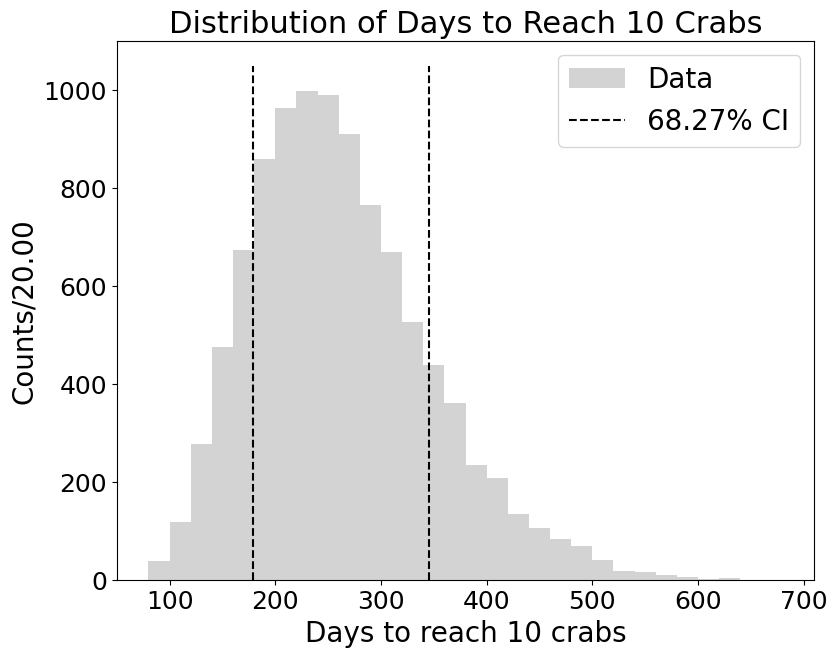

In [167]:
fig, ax = plt.subplots(figsize=(9, 7))
xmin, xmax = 80, 680
Nbins = 30
binwidth = (xmax - xmin) / Nbins
ax.hist(days, bins=Nbins, range=(xmin, xmax), color='lightgray', label='Data')
# ax.hist(days[(days > CI[0]) & (days < CI[1])], bins=Nbins, range=(xmin, xmax), color='red', alpha=0.3, label='Data within 68.27% CI')
ymin, ymax = ax.get_ylim()
ax.vlines(CI, ymin, ymax, linestyles='dashed', color='black', label='68.27% CI')
ax.set_xlabel('Days to reach 10 crabs', fontsize=20)
ax.set_ylabel(f'Counts/{binwidth:.2f}', fontsize=20)
ax.set_title('Distribution of Days to Reach 10 Crabs', fontsize=22)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.legend(fontsize=20);